# Multimodal House Price Prediction
### Predicting Real Estate Prices using Images and Tabular Data

This project implements a **Multimodal Machine Learning** model to predict housing prices. Unlike standard models that only use numbers, this model looks at both **house photos** and **structured features** (sqft, beds, baths) to make a more accurate prediction.

---

## Project Overview
In this task, we merged two different data types into one single Neural Network:
* **Tabular Branch:** Processes numerical data like square footage and room counts.
* **Image Branch (CNN):** Processes house images to extract visual features.
* **Late Fusion:** Both branches are merged (concatenated) to predict the final price.



---

## Technical Implementation
This project is specifically optimized for **Low-End Laptops** without a GPU:
* **Optimized Sampling:** Used a subset of 5,000 samples to ensure stable CPU training.
* **Custom CNN:** A lightweight Convolutional Neural Network was built to save memory.
* **Image Preprocessing:** Images were resized to 100x100 and normalized by 255.0 for faster convergence.

---

## Project Structure
* `data_csv/`: Contains the `socal2.csv` dataset.
* `images/`: Contains house images named by their `image_id`.
* `task.ipynb`: The main Jupyter Notebook with the training code.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
# 1. Set Paths

BASE_DIR = os.getcwd()
CSV_PATH = os.path.join(BASE_DIR, "data_csv", "socal2.csv")
IMAGE_FOLDER = os.path.join(BASE_DIR, "images")

In [3]:
# 2. Load Data

df = pd.read_csv(CSV_PATH)
# Reduce samples for low-end laptop
df = df.sample(5000, random_state=42)

In [4]:
# 3. Select Columns (Updated)

tabular_cols = ["bed", "bath", "sqft"]

df = df.dropna(subset=["price", "image_id"])
df = df[tabular_cols + ["price", "image_id"]]

In [5]:
# 4. Load Images

IMG_SIZE = 100

def load_images(image_ids):
    images = []
    for img_id in tqdm(image_ids):
        # assuming images are saved as image_id.jpg
        img_name = str(img_id) + ".jpg"
        img_path = os.path.join(IMAGE_FOLDER, img_name)
        
        try:
            img = Image.open(img_path).convert("RGB")
            img = img.resize((IMG_SIZE, IMG_SIZE))
            img = np.array(img) / 255.0
            images.append(img)
        except:
            images.append(np.zeros((IMG_SIZE, IMG_SIZE, 3)))
    
    return np.array(images)

image_data = load_images(df["image_id"].values)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [00:16<00:00, 307.46it/s]


In [6]:
# 5. Tabular Data

X_tabular = df[tabular_cols].values
y = df["price"].values

scaler = StandardScaler()
X_tabular = scaler.fit_transform(X_tabular)

In [7]:
# 6. Train Test Split

X_img_train, X_img_test, X_tab_train, X_tab_test, y_train, y_test = train_test_split(
    image_data, X_tabular, y, test_size=0.2, random_state=42
)

In [8]:
# 7. Image CNN

image_input = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = layers.Conv2D(16, (3,3), activation="relu")(image_input)
x = layers.MaxPooling2D()(x)

x = layers.Conv2D(32, (3,3), activation="relu")(x)
x = layers.MaxPooling2D()(x)

x = layers.Conv2D(64, (3,3), activation="relu")(x)
x = layers.GlobalAveragePooling2D()(x)

image_features = layers.Dense(32, activation="relu")(x)

In [9]:
# 8. Tabular Model

tabular_input = layers.Input(shape=(X_tab_train.shape[1],))

t = layers.Dense(32, activation="relu")(tabular_input)
t = layers.Dense(16, activation="relu")(t)

In [10]:
# 9. Combine Modalities

combined = layers.concatenate([image_features, t])

z = layers.Dense(32, activation="relu")(combined)
z = layers.Dense(16, activation="relu")(z)

output = layers.Dense(1)(z)

model = models.Model(inputs=[image_input, tabular_input], outputs=output)

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 100, 100, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d (Conv2D)               │ (None, 98, 98, 16)        │             448 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d (MaxPooling2D)  │ (None, 49, 49, 16)        │               0 │ conv2d[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_1 (Conv2D)             │ (None, 47, 47, 32)        │           4,640 │ max_pooling2d[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_1               │ (None, 23, 23, 32)        │               0 │ conv2d_1[0][0]             │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_2 (Conv2D)             │ (None, 21, 21, 64)        │          18,496 │ max_pooling2d_1[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ input_layer_1 (InputLayer)    │ (None, 3)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_average_pooling2d      │ (None, 64)                │               0 │ conv2d_2[0][0]             │
│ (GlobalAveragePooling2D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 32)                │             128 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 32)                │           2,080 │ global_average_pooling2d[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 16)                │             528 │ dense_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 48)                │               0 │ dense[0][0], dense_2[0][0] │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_3 (Dense)               │ (None, 32)                │           1,568 │ concatenate[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_4 (Dense)               │ (None, 16)                │             528 │ dense_3[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_5 (Dense)               │ (None, 1)                 │              17 │ dense_4[0][0]              │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 28,433 (111.07 KB)

 Trainable params: 28,433 (111.07 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# 10. Train

history = model.fit(
    [X_img_train, X_tab_train],
    y_train,
    validation_data=([X_img_test, X_tab_test], y_test),
    epochs=5,
    batch_size=8
)

Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - loss: 385397587968.0000 - mae: 487217.0312 - val_loss: 164185784320.0000 - val_mae: 293607.5625
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - loss: 151347052544.0000 - mae: 286579.0938 - val_loss: 157845110784.0000 - val_mae: 290425.4062
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - loss: 145002528768.0000 - mae: 279219.8750 - val_loss: 142706311168.0000 - val_mae: 276950.3438
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - loss: 133294514176.0000 - mae: 265365.1250 - val_loss: 123628019712.0000 - val_mae: 261120.7344
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - loss: 120028618752.0000 - mae: 254869.8281 - val_loss: 113267097600.0000 - val_mae: 244087.8906


In [12]:
# 11. Evaluation

preds = model.predict([X_img_test, X_tab_test])

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))

print("\nFinal Results:")
print("MAE :", mae)
print("RMSE:", rmse)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step

Final Results:
MAE : 244087.90625
RMSE: 336551.76334109437


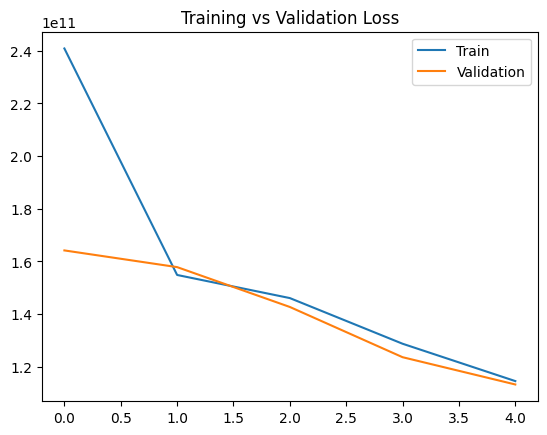

In [13]:
# 12. Plot

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Training vs Validation Loss")
plt.legend(["Train", "Validation"])
plt.show()


In [14]:
def predict_house_price(index_to_test):
    # 1. Extracting image and tabular data from test data
    test_img = X_img_test[index_to_test:index_to_test+1]
    test_tab = X_tab_test[index_to_test:index_to_test+1]
    actual_price = y_test[index_to_test]

    # 2. Getting predictions from the model
    predicted_price = model.predict([test_img, test_tab])[0][0]

    # 3. Display Result
    print(f"\n--- Prediction Result ---")
    print(f"Actual Price: ${actual_price:,.2f}")
    print(f"Predicted Price: ${predicted_price:,.2f}")
    print(f"Difference: ${abs(actual_price - predicted_price):,.2f}")

    # 4. Showing images
    plt.imshow(test_img[0])
    plt.title(f"Predicted: ${predicted_price:,.0f} | Actual: ${actual_price:,.0f}")
    plt.axis('off')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step

--- Prediction Result ---
Actual Price: $749,999.00
Predicted Price: $864,257.81
Difference: $114,258.81


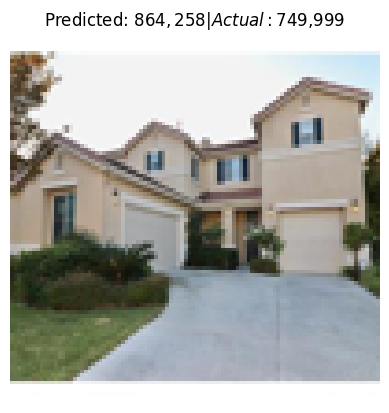

In [15]:
# Provide any index number to test (from 0 to take(q_ing_test)).
predict_house_price(index_to_test=10)